Libraries imported and styles set.
Loading enhanced dataset from: ../../data/processed/enhanced_features_dataset.csv
Loaded enhanced dataset: 2000 rows, 90 columns
Loading stable features from: ../../src/models/stable_features.txt
Loaded 7 stable features

Detailed Attack Type Distribution:
attack_type
Normal             1999
Brute Force-Web       1
Name: count, dtype: int64

Column names:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header L

C:\Users\mcgahanc\AppData\Local\miniconda3\envs\api_security_ml\lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(



Best parameters: {'bootstrap': True, 'contamination': 0.01, 'max_features': 0.5, 'max_samples': 'auto', 'n_estimators': 100}
Best F1 score: nan
Best parameters saved to src/models/best_parameters.json


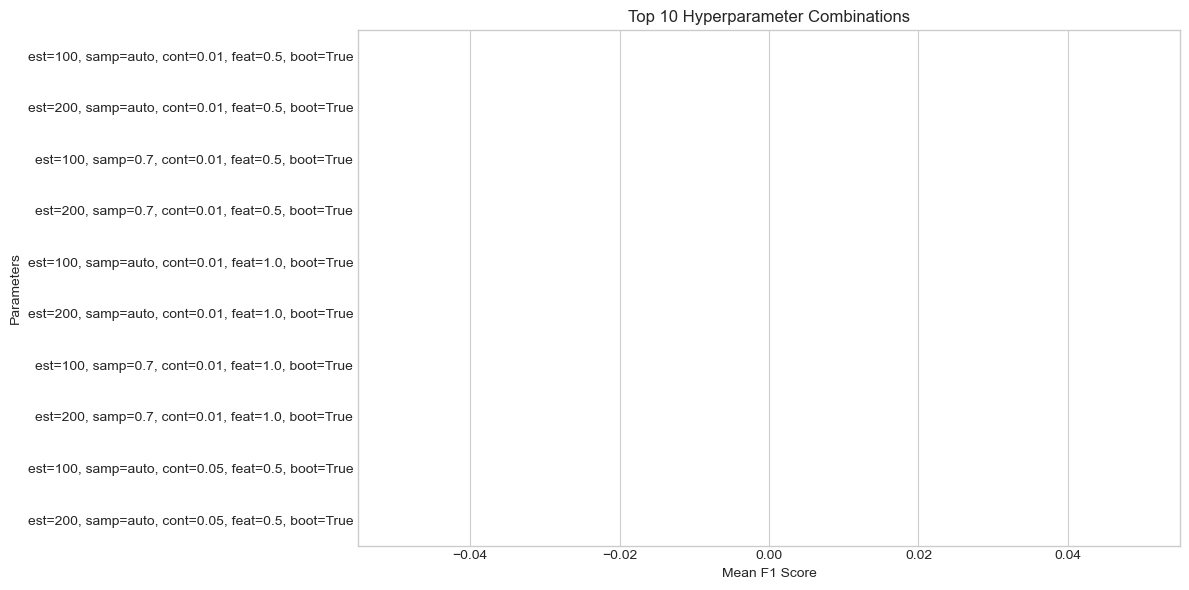

Error during grid search: '<' not supported between instances of 'str' and 'float'

Trying alternative approach with predefined configurations...
Testing configuration: {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.01, 'max_features': 1.0, 'bootstrap': True}
Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Testing configuration: {'n_estimators': 200, 'max_samples': 0.7, 'contamination': 0.05, 'max_features': 0.7, 'bootstrap': True}
Precision: 0.3182, Recall: 0.3500, F1: 0.3333
Testing configuration: {'n_estimators': 50, 'max_samples': 'auto', 'contamination': 0.1, 'max_features': 0.5, 'bootstrap': True}
Precision: 0.5882, Recall: 0.5000, F1: 0.5405

Best configuration: {'n_estimators': 50, 'max_samples': 'auto', 'contamination': 0.1, 'max_features': 0.5, 'bootstrap': True}
Best F1 score: 0.5405
Best parameters saved to src/models/best_parameters.json


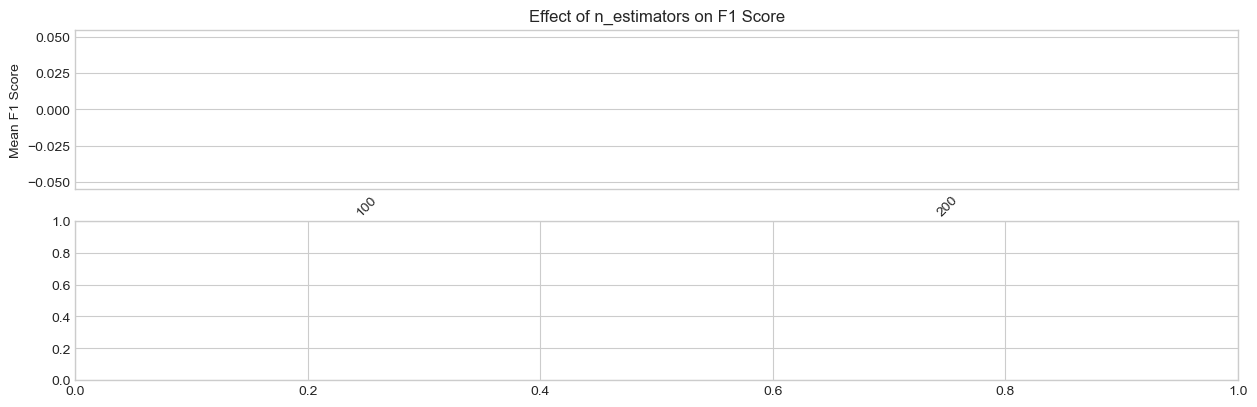

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, make_scorer, precision_score, recall_score, f1_score
from functools import partial

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print("Libraries imported and styles set.")

# Load enhanced dataset and stable features
def load_data_and_features():
    """Load the enhanced dataset and stable features"""
    dataset_path = '../../data/processed/enhanced_features_dataset.csv'
    features_path = '../../src/models/stable_features.txt'
    
    if os.path.exists(dataset_path):
        print(f"Loading enhanced dataset from: {dataset_path}")
        try:
            df = pd.read_csv(dataset_path)
            print(f"Loaded enhanced dataset: {df.shape[0]} rows, {df.shape[1]} columns")
        except Exception as e:
            print(f"Error loading enhanced dataset: {e}")
            return None, []
    else:
        print(f"Enhanced dataset not found at {dataset_path}")
        return None, []
    
    if os.path.exists(features_path):
        print(f"Loading stable features from: {features_path}")
        try:
            with open(features_path, 'r') as f:
                features = [line.strip() for line in f if line.strip()]
            print(f"Loaded {len(features)} stable features")
        except Exception as e:
            print(f"Error loading stable features: {e}")
            return df, []
    else:
        print(f"Stable features file not found at {features_path}")
        return df, []
    
    return df, features

# Load best balancing approach
def load_best_balancing():
    """Load the best balancing approach from previous notebook"""
    balancing_path = '../../src/models/best_balancing.json'
    
    if os.path.exists(balancing_path):
        print(f"Loading best balancing approach from: {balancing_path}")
        try:
            with open(balancing_path, 'r') as f:
                balancing = json.load(f)
            print(f"Best balancing: {balancing['method']} with ratio {balancing['ratio']}")
            return balancing
        except Exception as e:
            print(f"Error loading best balancing approach: {e}")
            return {
                'method': 'undersampling',
                'ratio': 1.0,
                'threshold': -0.06
            }
    else:
        print(f"Best balancing file not found at {balancing_path}. Using default.")
        return {
            'method': 'undersampling',
            'ratio': 1.0,
            'threshold': -0.06
        }

# Load data
df, stable_features = load_data_and_features()

# Diagnostic print for dataset contents
if df is not None:
    print("\nDetailed Attack Type Distribution:")
    print(df['attack_type'].value_counts())
    
    print("\nColumn names:")
    print(df.columns.tolist())
    
    print("\nSample rows:")
    print(df.head())

best_balancing = load_best_balancing()

# Function to create synthetic attack samples (NEW)
def create_synthetic_attack_samples(original_attack_df, feature_cols, n_synthetic=10):
    """Create synthetic attack samples by adding controlled noise to original attack sample"""
    synthetic_samples = []
    
    for _, original_sample in original_attack_df.iterrows():
        for i in range(n_synthetic):
            # Create a copy of the original sample
            new_sample = original_sample.copy()
            
            # Add small random variations (±10%) to numeric features
            for feature in feature_cols:
                if feature in new_sample and pd.api.types.is_numeric_dtype(original_attack_df[feature]):
                    # Get original value (handle zero values)
                    orig_value = new_sample[feature]
                    if orig_value != 0:
                        variation = np.random.uniform(0.9, 1.1)  # ±10% variation
                        new_sample[feature] = orig_value * variation
                    else:
                        # For zero values, add a small random value instead
                        new_sample[feature] = np.random.uniform(0, 0.1)
                    
            synthetic_samples.append(new_sample)
    
    return pd.DataFrame(synthetic_samples)

# Create synthetic attack samples (NEW)
if df is not None:
    print("\nCreating synthetic attack samples...")
    attack_samples = df[df['is_attack'] == True]
    print(f"Original attack samples: {len(attack_samples)}")

    # If there are any attack samples, create synthetic ones
    if len(attack_samples) > 0:
        synthetic_attacks = create_synthetic_attack_samples(attack_samples, stable_features, n_synthetic=19)
        synthetic_attacks['is_attack'] = True
        synthetic_attacks['attack_type'] = 'Brute Force-Web'  # Match original label

        # Copy over any non-feature columns that might be needed
        for col in attack_samples.columns:
            if col not in synthetic_attacks.columns and col not in stable_features:
                synthetic_attacks[col] = attack_samples[col].values[0]

        # Combine with original data
        df_augmented = pd.concat([df, synthetic_attacks], ignore_index=True)
        print(f"Dataset after augmentation: {len(df_augmented)} samples")
        print(f"Attack samples after augmentation: {len(df_augmented[df_augmented['is_attack'] == True])}")

        # Replace original df with augmented version
        df = df_augmented
    else:
        print("No attack samples found, cannot create synthetic samples")

# Prepare dataset using best balancing approach
def create_balanced_dataset(df, method='undersampling', ratio=1.0):
    """Create a balanced dataset using different methods"""
    if df is None:
        print("DataFrame is None. Cannot create balanced dataset.")
        return None, None
    
    if 'is_attack' not in df.columns:
        print("No 'is_attack' column found. Creating it from attack_type.")
        df['is_attack'] = df['attack_type'] != 'Normal'
    
    normal_df = df[df['is_attack'] == False]
    attack_df = df[df['is_attack'] == True]
    
    n_attacks = len(attack_df)
    n_normal = len(normal_df)
    
    print(f"\nDetailed Dataset Composition:")
    print(f"Total samples: {len(df)}")
    print(f"Normal samples: {n_normal}")
    print(f"Attack samples: {n_attacks}")
    print("\nAttack Type Breakdown:")
    print(df['attack_type'].value_counts())
    
    if n_attacks == 0:
        print("Warning: No attack samples found in dataset.")
        return df, None  # Return original dataset
    
    # Change method if not enough attack samples for SMOTE (NEW)
    if n_attacks < 2 and method == 'smote':
        print(f"Too few attack samples ({n_attacks}) for SMOTE. Switching to undersampling.")
        method = 'undersampling'  # Fallback to undersampling
    
    if method == 'undersampling':
        # Undersampling majority class
        n_normal_sampled = int(n_attacks * ratio)
        n_normal_sampled = min(n_normal_sampled, n_normal)  # Ensure we don't request more than available
        
        normal_sampled = normal_df.sample(n=n_normal_sampled, random_state=42)
        balanced_df = pd.concat([normal_sampled, attack_df])
        
        print(f"Undersampling: Created dataset with {n_normal_sampled} normal samples (ratio {ratio}:1)")
        
        class_weight = None  # No class weight for undersampling
        
    elif method == 'weighted':
        # Return original dataset with class weights
        balanced_df = df.copy()
        
        # Calculate class weights
        class_weight = {
            False: 1,
            True: ratio * n_normal / n_attacks
        }
        
        print(f"Weighted: Using original dataset with class weights: {class_weight}")
        
    else:
        print(f"Unknown balancing method: {method}. Using original dataset.")
        balanced_df = df.copy()
        class_weight = None
    
    return balanced_df, class_weight

if df is not None:
    print("\nPreparing dataset with best balancing approach...")
    balanced_df, class_weight = create_balanced_dataset(
        df, 
        method=best_balancing.get('method', 'undersampling'),
        ratio=best_balancing.get('ratio', 1.0)
    )
    
    if balanced_df is not None:
        print(f"Balanced dataset shape: {balanced_df.shape}")
        
        # Check if we have features
        if not stable_features:
            print("No stable features available. Using all numeric features.")
            feature_cols = balanced_df.select_dtypes(include=np.number).columns.tolist()
            feature_cols = [col for col in feature_cols if col not in ['is_attack']]
        else:
            feature_cols = [f for f in stable_features if f in balanced_df.columns]
        
        if len(feature_cols) > 0:
            print(f"Using {len(feature_cols)} features for training: {feature_cols}")
        else:
            print("No valid features available for training.")
    else:
        print("Failed to create balanced dataset.")
else:
    print("Cannot prepare dataset. DataFrame not available.")

# Custom scorer for Isolation Forest
def custom_iforest_scorer(estimator, X, y_true, threshold=None):
    """
    Custom scorer for Isolation Forest anomaly detection.
    If threshold is None, finds the optimal threshold.
    """
    scores = estimator.decision_function(X)
    
    if threshold is None:
        # Find optimal threshold
        thresholds = np.linspace(min(scores), max(scores), 100)
        best_f1 = 0
        best_threshold = 0
        
        for t in thresholds:
            y_pred = (scores <= t).astype(int)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, average='binary', zero_division=0
            )
            
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = t
        
        y_pred = (scores <= best_threshold).astype(int)
    else:
        y_pred = (scores <= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    
    return f1

# Hyperparameter tuning with cross-validation
if 'balanced_df' in locals() and balanced_df is not None and 'feature_cols' in locals() and len(feature_cols) > 0:
    print("\nSetting up cross-validation for hyperparameter tuning...")
    
    # Prepare data
    X = balanced_df[feature_cols]
    y = balanced_df['is_attack']
    
    # Choose CV strategy based on available attack samples (NEW)
    attack_count = len(balanced_df[balanced_df['is_attack'] == True])
    print(f"Number of attack samples for cross-validation: {attack_count}")
    
    if attack_count < 5:
        print("Using regular KFold instead of StratifiedKFold due to limited attack samples")
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
    else:
        print("Using StratifiedKFold cross-validation")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Simplified parameter grid (NEW)
    param_grid = {
        'n_estimators': [100, 200],          # Reduced from [50, 100, 200]
        'max_samples': ['auto', 0.7],        # Reduced from ['auto', 0.5, 0.7, 1.0]
        'contamination': [0.01, 0.05, 0.1],  # Reduced from [0.01, 0.05, 0.1, 0.2, 0.5]
        'max_features': [0.5, 1.0],          # Reduced from [0.5, 0.7, 1.0]
        'bootstrap': [True]                  # Reduced from [True, False]
    }
    
    print(f"Hyperparameter grid: {param_grid}")
    total_combinations = np.prod([len(values) for values in param_grid.values()])
    print(f"Total combinations to evaluate: {total_combinations}")
    
    # Setup Isolation Forest
    iforest = IsolationForest(random_state=42)
    
    # Create scorer with fixed threshold from balancing optimization
    threshold = best_balancing.get('threshold', None)
    if threshold is not None:
        print(f"Using fixed threshold from balancing optimization: {threshold}")
        scorer = partial(custom_iforest_scorer, threshold=threshold)
    else:
        print("Will find optimal threshold during cross-validation")
        scorer = custom_iforest_scorer
    
    # Wrap scorer for grid search
    iforest_scorer = make_scorer(scorer)
    
    # Setup grid search
    grid_search = GridSearchCV(
        estimator=iforest,
        param_grid=param_grid,
        cv=cv,
        scoring=iforest_scorer,
        verbose=1,
        n_jobs=-1  # Use all available cores
    )
    
    # Run grid search
    print("\nStarting grid search for hyperparameter tuning...")
    try:
        # Note: For Isolation Forest, we typically want to fit only on normal samples
        # But our custom scorer requires both normal and attack samples
        grid_search.fit(X, y)
        
        # Get best parameters
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        print(f"\nBest parameters: {best_params}")
        print(f"Best F1 score: {best_score:.4f}")
        
        # Save best parameters
        os.makedirs('../../src/models', exist_ok=True)
        with open('../../src/models/best_parameters.json', 'w') as f:
            json.dump({
                'best_params': best_params,
                'best_score': float(best_score),
                'threshold': float(threshold) if threshold is not None else None
            }, f, indent=4)
        
        print("Best parameters saved to src/models/best_parameters.json")
        
        # Plot top results
        results = pd.DataFrame(grid_search.cv_results_)
        
        # Sort by mean test score
        top_results = results.sort_values('mean_test_score', ascending=False).head(10)
        
        # Create a readable format for parameters
        top_results['params_str'] = top_results['params'].apply(
            lambda p: f"est={p['n_estimators']}, samp={p['max_samples']}, cont={p['contamination']}, feat={p['max_features']}, boot={p['bootstrap']}"
        )
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x='mean_test_score', y='params_str', data=top_results)
        plt.xlabel('Mean F1 Score')
        plt.ylabel('Parameters')
        plt.title('Top 10 Hyperparameter Combinations')
        plt.tight_layout()
        plt.show()
        
        # Investigate parameter importance
        plt.figure(figsize=(15, 12))
        
        # Plot for each parameter
        param_names = list(param_grid.keys())
        for i, param in enumerate(param_names):
            plt.subplot(len(param_names), 1, i+1)
            
            # Group by parameter and calculate mean score
            param_results = results.groupby(f'param_{param}')['mean_test_score'].mean().reset_index()
            
            # Sort by parameter value
            if not param_results.empty:
                param_results = param_results.sort_values(f'param_{param}')
                
                # Ensure all values are strings for consistent plotting
                param_results[f'param_{param}'] = param_results[f'param_{param}'].astype(str)
                
                sns.barplot(x=f'param_{param}', y='mean_test_score', data=param_results)
                plt.title(f'Effect of {param} on F1 Score')
                plt.ylabel('Mean F1 Score')
                plt.xlabel(param)
                plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error during grid search: {e}")
        
        # Alternative approach if grid search fails (NEW)
        print("\nTrying alternative approach with predefined configurations...")

        # Define a few reasonable configurations
        configs = [
            {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.01, 'max_features': 1.0, 'bootstrap': True},
            {'n_estimators': 200, 'max_samples': 0.7, 'contamination': 0.05, 'max_features': 0.7, 'bootstrap': True},
            {'n_estimators': 50, 'max_samples': 'auto', 'contamination': 0.1, 'max_features': 0.5, 'bootstrap': True}
        ]

        X = balanced_df[feature_cols]
        y = balanced_df['is_attack'].astype(int)
        fixed_threshold = best_balancing.get('threshold', -0.06)

        results = []
        for params in configs:
            print(f"Testing configuration: {params}")
            model = IsolationForest(random_state=42, **params)
            
            # Train on normal samples only as is typical for Isolation Forest
            model.fit(X[y == 0])
            
            # Score on all samples
            scores = model.decision_function(X)
            
            # Use threshold from balancing optimization
            y_pred = (scores <= fixed_threshold).astype(int)
            
            # Calculate metrics
            precision = precision_score(y, y_pred, zero_division=0)
            recall = recall_score(y, y_pred, zero_division=0)
            f1 = f1_score(y, y_pred, zero_division=0)
            
            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
            results.append((params, f1))

        # Get best configuration
        if results:
            best_params, best_f1 = max(results, key=lambda x: x[1])
            print(f"\nBest configuration: {best_params}")
            print(f"Best F1 score: {best_f1:.4f}")
            
            # Save the best parameters
            with open('../../src/models/best_parameters.json', 'w') as f:
                json.dump(best_params, f, indent=4)
            print("Best parameters saved to src/models/best_parameters.json")
        else:
            print("All configurations failed.")
else:
    print("Cannot perform hyperparameter tuning. Required data not available.")